In [1]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
# ============================================================
# CELL 1 — Imports and constants
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

FOURIER_CAL_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_fourier_pre_wavefront_00000.h5"
)

WAVELENGTH_UM = 0.7593
CAMERA_SERIAL = "015C2"

SUPERPIXEL_SIZE = 80

# 16-pixel carrier
CARRIER_KXY = np.array([0.00593203125, 0.0])

# Same dump point we were using
DUMP_KXY = np.array([0.0, 0.00593203125])

print("Startup constants loaded.")

Startup constants loaded.


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


In [3]:
# ============================================================
# CELL 2 — Initialize SLM
# ============================================================

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=WAVELENGTH_UM,
    verbose=True,
)

print("SLM initialized.")
print("Shape:", slm.shape)
print("Pitch [um]:", slm.pitch_um)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...SLM initialized.
Shape: (1200, 1920)
Pitch [um]: [8. 8.]


In [4]:
# ============================================================
# CELL 3 — Initialize Allied Vision camera
# ============================================================

cam = AlliedVision(
    serial=CAMERA_SERIAL,
    verbose=True,
)

print("Camera initialized.")
print("Shape:", cam.shape)
print("Pitch [um]:", cam.pitch_um)
print("Exposure [s]:", cam.exposure_s)

vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
Camera initialized.
Shape: (3672, 5496)
Pitch [um]: None
Exposure [s]: 0.0050071809999999994


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


In [5]:
# ============================================================
# CELL 4 — Set exposure and verify one camera frame
# ============================================================

cam.set_exposure(0.020)

img_test = cam.get_image()

print("Actual exposure [s]:", cam.exposure_s)
print("Image shape:", img_test.shape)
print("Min:", img_test.min())
print("Max:", img_test.max())
print("Mean:", img_test.mean())

Actual exposure [s]: 0.019994681
Image shape: (3672, 5496)
Min: 0
Max: 36
Mean: 3.0966174548017493


In [6]:
# ============================================================
# CELL 5 — Create FourierSLM and reload Fourier calibration
# ============================================================

fs = FourierSLM(cam, slm)

fs.load_calibration(
    "fourier",
    str(FOURIER_CAL_PATH)
)

print("Loaded calibrations:")
print(fs.calibrations.keys())

print("\nStored M:")
print(fs.calibrations["fourier"]["M"])

print("\nStored a:")
print(fs.calibrations["fourier"]["a"])

print("\nStored b:")
print(fs.calibrations["fourier"]["b"])

Loaded calibrations:
dict_keys(['fourier'])

Stored M:
[[-1.06337229e+05 -1.41055175e+02]
 [ 2.79442892e+01  1.04398063e+05]]

Stored a:
[[0]
 [0]]

Stored b:
[[4366.83233079]
 [1826.79508478]]


In [7]:
# ============================================================
# CELL 6 — Verify Fourier mapping
# ============================================================

zero_ij = fs.kxyslm_to_ijcam(
    np.array([0.0, 0.0])
).ravel()

carrier_ij = fs.kxyslm_to_ijcam(
    CARRIER_KXY
).ravel()

print("Zero order camera ij:")
print(zero_ij)

print("\n16-pixel carrier camera ij:")
print(carrier_ij)

print("\nCarrier displacement from zero order:")
print(carrier_ij - zero_ij)

Zero order camera ij:
[4366.83233079 1826.79508478]

16-pixel carrier camera ij:
[3736.03656654 1826.96085117]

Carrier displacement from zero order:
[-6.30795764e+02  1.65766397e-01]


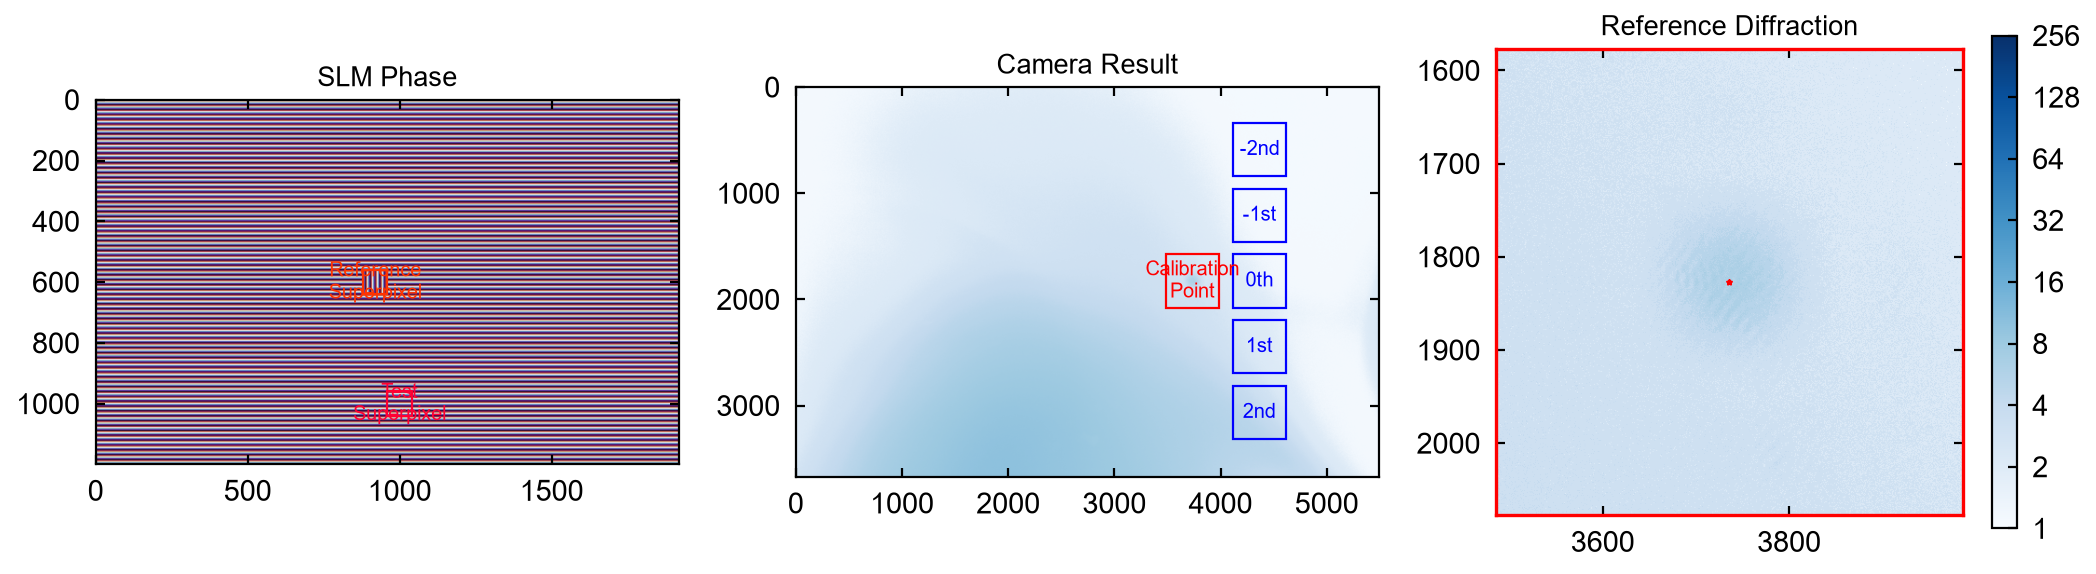

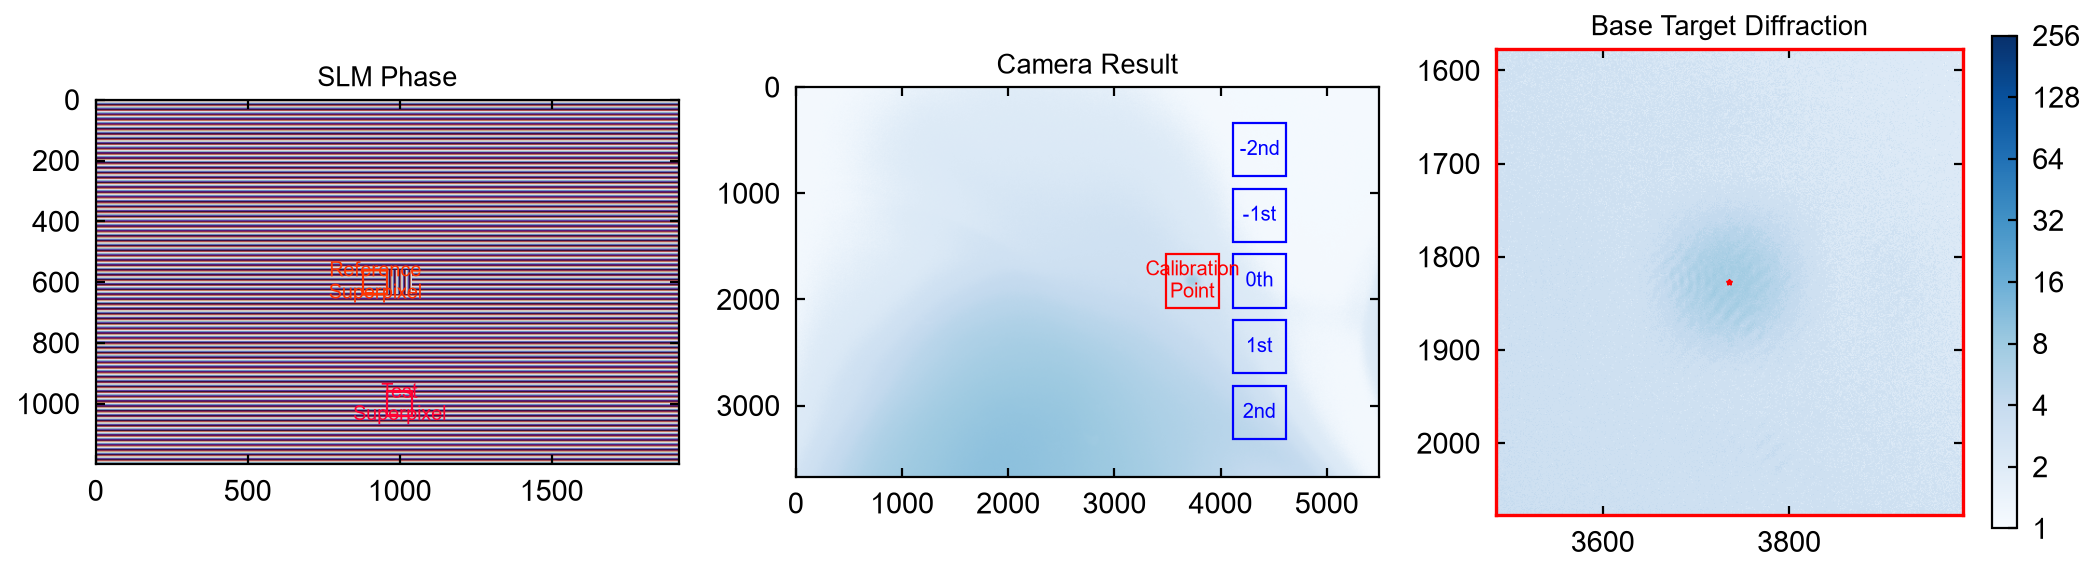

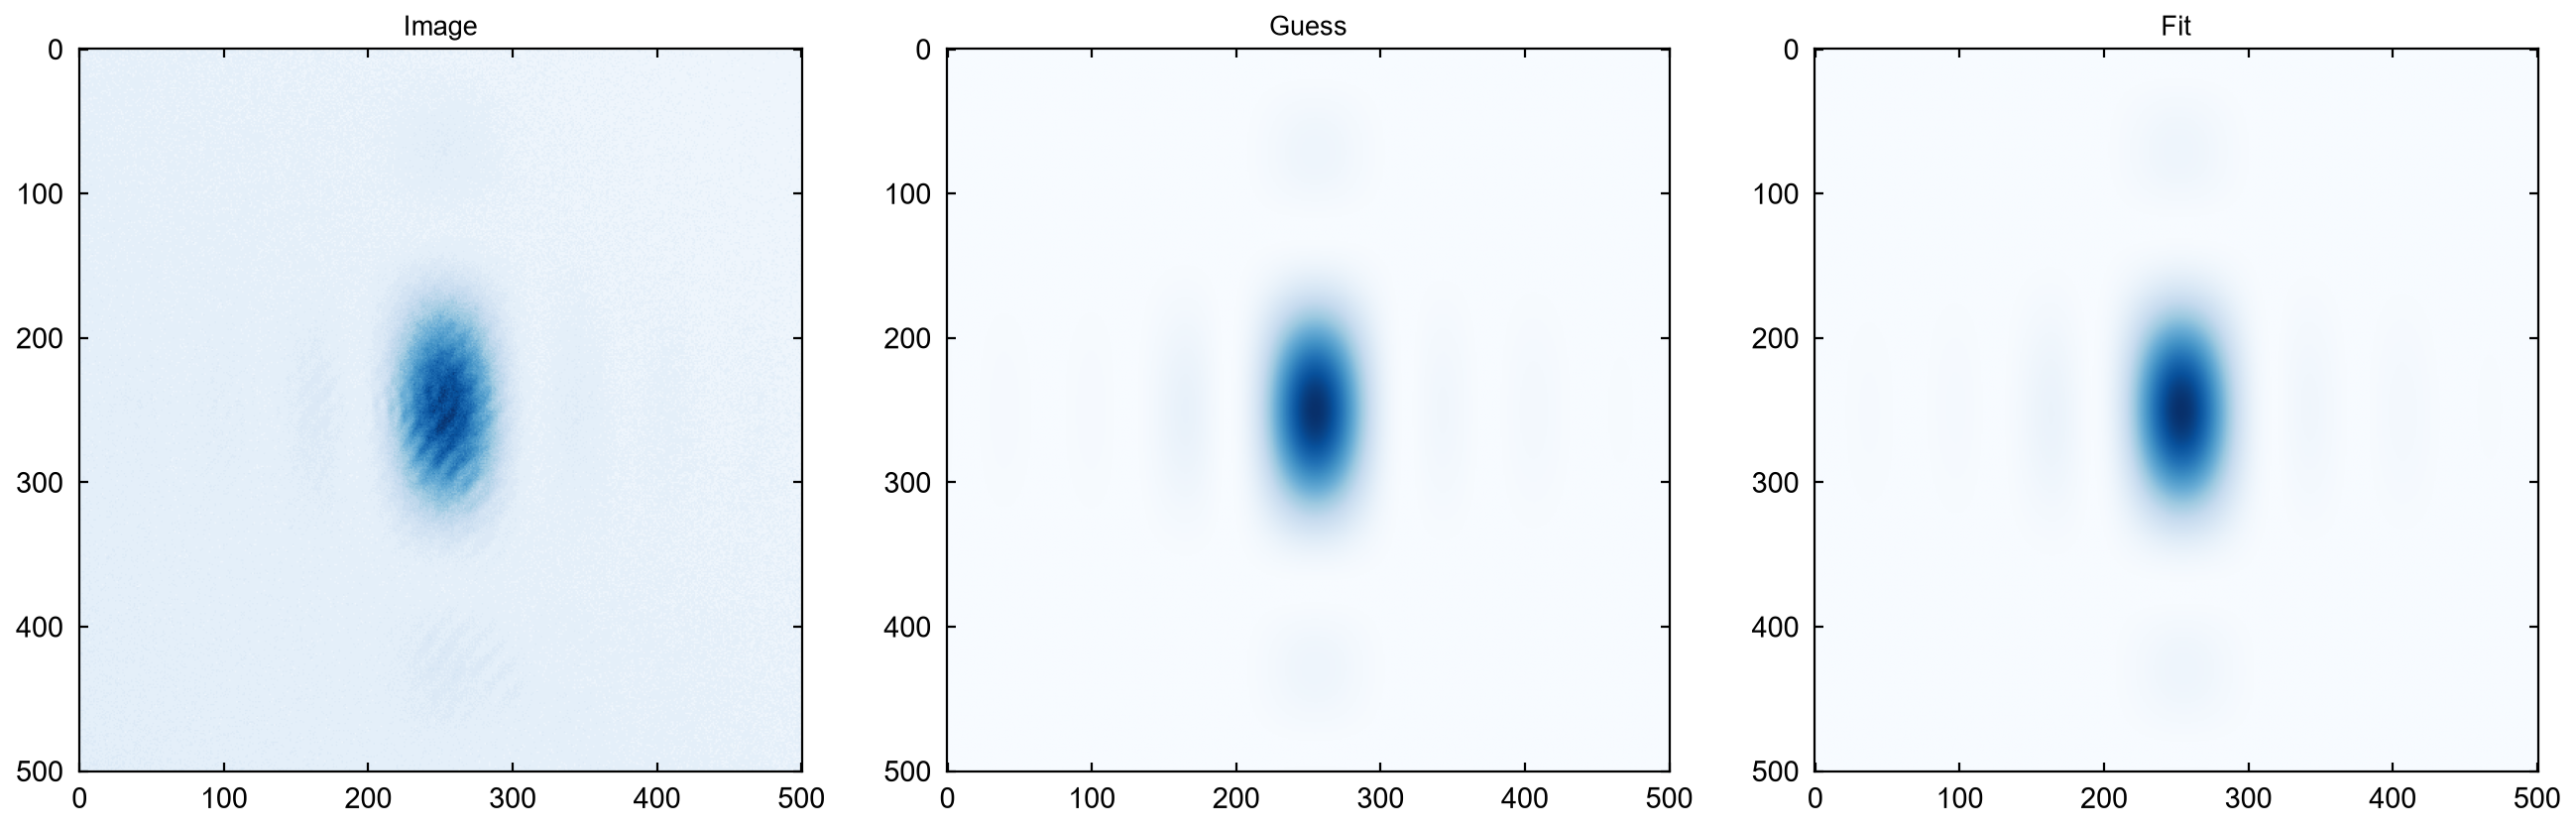

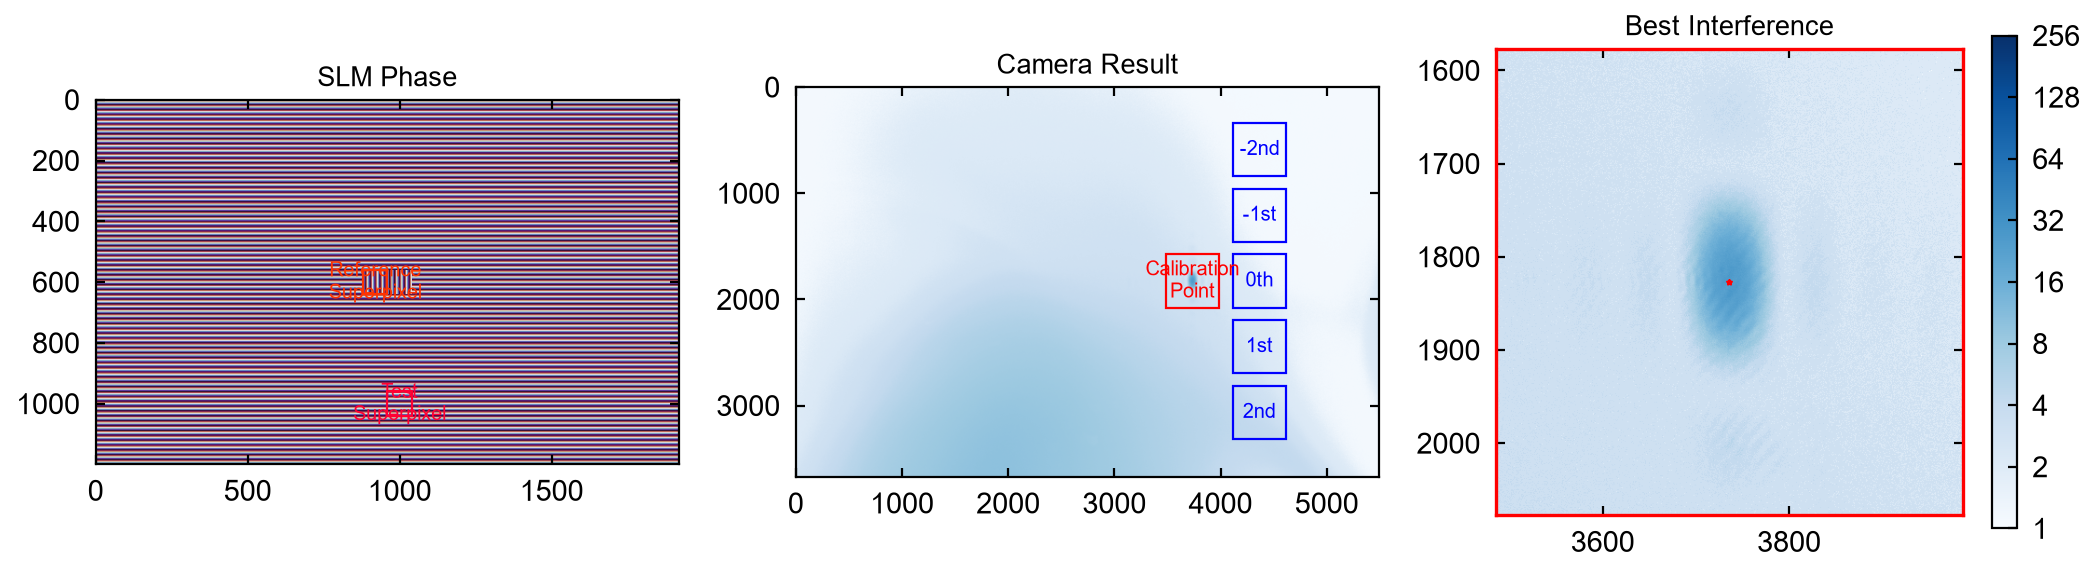


phase        = [0.23565899]
amp_fit      = [18.55830957]
contrast_fit = [0.82812681]
r2_fit       = [0.9916592]
kx           = [-8.45386643e-06]
ky           = [-3.47237139e-06]


In [8]:
# ============================================================
# CELL 7 — Central superpixel test after iris + power change
# ============================================================

result_iris = fs.wavefront_calibrate_superpixel(
    calibration_points=carrier_ij.ravel(),

    superpixel_size=SUPERPIXEL_SIZE,
    reference_superpixels=(11, 7),
    exclude_superpixels=(0, 0),

    test_index=0,

    field_point=DUMP_KXY,
    field_point_units="kxy",

    phase_steps=1,

    fresh_calibration=True,
    measure_background=False,
    corrected_amplitude=False,

    plot=1,
)

print("\nphase        =", result_iris["phase"])
print("amp_fit      =", result_iris["amp_fit"])
print("contrast_fit =", result_iris["contrast_fit"])
print("r2_fit       =", result_iris["r2_fit"])
print("kx           =", result_iris["kx"])
print("ky           =", result_iris["ky"])

In [12]:
# ============================================================
# CELL 8 — Check two additional illuminated superpixels
# ============================================================

test_indices = [100, 240]

for idx in test_indices:

    res = fs.wavefront_calibrate_superpixel(
        calibration_points=carrier_ij.ravel(),

        superpixel_size=SUPERPIXEL_SIZE,
        reference_superpixels=(11, 7),
        exclude_superpixels=(0, 0),

        test_index=idx,

        field_point=DUMP_KXY,
        field_point_units="kxy",

        phase_steps=1,

        fresh_calibration=True,
        measure_background=False,
        corrected_amplitude=False,

        plot=0,
    )

    print("\n--------------------------------")
    print("test_index =", idx)
    print("phase      =", float(np.asarray(res["phase"]).ravel()[0]))
    print("R^2        =", float(np.asarray(res["r2_fit"]).ravel()[0]))
    print("contrast   =", float(np.asarray(res["contrast_fit"]).ravel()[0]))


--------------------------------
test_index = 100
phase      = 0.11800391553609763
R^2        = 0.8432882220292501
contrast   = 0.8814383292258404

--------------------------------
test_index = 240
phase      = 0.5244553686652385
R^2        = 0.9701130730142676
contrast   = 0.9364440216893071


In [14]:
# ============================================================
# REPEATABILITY TEST — do not touch anything while this runs
# ============================================================

test_indices = [100, 240]
N_REPEAT = 5

for idx in test_indices:

    phases = []
    r2s = []
    contrasts = []

    print("\n" + "="*60)
    print("test_index =", idx)
    print("="*60)

    for n in range(N_REPEAT):

        res = fs.wavefront_calibrate_superpixel(
            calibration_points=carrier_ij.ravel(),
            superpixel_size=SUPERPIXEL_SIZE,
            reference_superpixels=(11, 7),
            exclude_superpixels=(0, 0),

            test_index=idx,

            field_point=DUMP_KXY,
            field_point_units="kxy",

            phase_steps=1,
            fresh_calibration=True,
            measure_background=False,
            corrected_amplitude=False,

            plot=0,
        )

        ph = float(np.asarray(res["phase"]).ravel()[0])
        r2 = float(np.asarray(res["r2_fit"]).ravel()[0])
        con = float(np.asarray(res["contrast_fit"]).ravel()[0])

        phases.append(ph)
        r2s.append(r2)
        contrasts.append(con)

        print(
            f"repeat {n+1}: "
            f"phase={ph:.4f}, "
            f"R2={r2:.4f}, "
            f"contrast={con:.4f}"
        )

    phases = np.asarray(phases)

    # Circular phase statistics
    mean_phase = np.angle(np.mean(np.exp(1j * phases)))

    phase_errors = np.angle(
        np.exp(1j * (phases - mean_phase))
    )

    print("\nCircular mean phase =", mean_phase)
    print("Phase deviations [rad] =", phase_errors)
    print("RMS phase deviation =", np.sqrt(np.mean(phase_errors**2)))

    print("Mean R2 =", np.mean(r2s))
    print("Mean contrast =", np.mean(contrasts))


test_index = 100
repeat 1: phase=2.2156, R2=0.8466, contrast=0.5451
repeat 2: phase=1.8944, R2=0.9872, contrast=0.6600
repeat 3: phase=1.3109, R2=1.0000, contrast=0.6365
repeat 4: phase=0.0855, R2=0.8955, contrast=0.8198
repeat 5: phase=1.4746, R2=1.0000, contrast=0.6797

Circular mean phase = 1.457890069917228
Phase deviations [rad] = [ 0.75772939  0.43652299 -0.14694558 -1.37243581  0.01674416]
RMS phase deviation = 0.7307748725756158
Mean R2 = 0.9458691883402416
Mean contrast = 0.6682148361204998

test_index = 240
repeat 1: phase=0.4254, R2=0.9858, contrast=0.9192
repeat 2: phase=0.4642, R2=0.9803, contrast=0.9297
repeat 3: phase=0.3231, R2=0.9873, contrast=0.9228
repeat 4: phase=0.4310, R2=0.9927, contrast=0.9116
repeat 5: phase=0.1817, R2=0.9984, contrast=0.9048

Circular mean phase = 0.36526218610870637
Phase deviations [rad] = [ 0.06018207  0.09890103 -0.04212398  0.06577232 -0.18352755]
RMS phase deviation = 0.10313688536889262
Mean R2 = 0.9888895171465227
Mean contrast = 0.91

In [15]:
# ============================================================
# NEXT CELL — Increase exposure only
# ============================================================

cam.set_exposure(0.050)

img_check = cam.get_image()

print("Actual exposure [s]:", cam.exposure_s)
print("Image min :", img_check.min())
print("Image max :", img_check.max())
print("Image mean:", img_check.mean())

Actual exposure [s]: 0.049997180999999995
Image min : 0
Image max : 70
Image mean: 0.022969567092565635


In [16]:
# ============================================================
# NEXT CELL — Repeatability of index 100 at 50 ms
# ============================================================

idx = 100
N_REPEAT = 5

phases = []
r2s = []
contrasts = []

for n in range(N_REPEAT):

    res = fs.wavefront_calibrate_superpixel(
        calibration_points=carrier_ij.ravel(),
        superpixel_size=SUPERPIXEL_SIZE,
        reference_superpixels=(11, 7),
        exclude_superpixels=(0, 0),

        test_index=idx,

        field_point=DUMP_KXY,
        field_point_units="kxy",

        phase_steps=1,
        fresh_calibration=True,
        measure_background=False,
        corrected_amplitude=False,

        plot=0,
    )

    ph = float(np.asarray(res["phase"]).ravel()[0])
    r2 = float(np.asarray(res["r2_fit"]).ravel()[0])
    con = float(np.asarray(res["contrast_fit"]).ravel()[0])

    phases.append(ph)
    r2s.append(r2)
    contrasts.append(con)

    print(
        f"repeat {n+1}: "
        f"phase={ph:.4f}, "
        f"R2={r2:.4f}, "
        f"contrast={con:.4f}"
    )


phases = np.asarray(phases)

mean_phase = np.angle(
    np.mean(np.exp(1j * phases))
)

phase_errors = np.angle(
    np.exp(1j * (phases - mean_phase))
)

print("\nCircular mean phase =", mean_phase)
print("Phase deviations [rad] =", phase_errors)
print(
    "RMS phase deviation =",
    np.sqrt(np.mean(phase_errors**2))
)

print("Mean R2 =", np.mean(r2s))
print("Mean contrast =", np.mean(contrasts))

repeat 1: phase=0.5872, R2=0.9884, contrast=0.7020
repeat 2: phase=5.4545, R2=0.8566, contrast=0.8893
repeat 3: phase=5.3253, R2=0.8644, contrast=0.8862
repeat 4: phase=0.5270, R2=0.9409, contrast=0.7581
repeat 5: phase=5.8344, R2=0.8413, contrast=0.9053

Circular mean phase = -0.23758205331846846
Phase deviations [rad] = [ 0.82473757 -0.5910822  -0.72033349  0.76453792 -0.21124561]
RMS phase deviation = 0.6599384035895868
Mean R2 = 0.8983252321320194
Mean contrast = 0.8281858385749811


In [17]:
# ============================================================
# TEST — Does camera flushing fix index-100 repeatability?
# ============================================================

idx = 100
N_REPEAT = 5

phases = []
r2s = []
contrasts = []

for n in range(N_REPEAT):

    # Important new step
    cam.flush()

    res = fs.wavefront_calibrate_superpixel(
        calibration_points=carrier_ij.ravel(),
        superpixel_size=SUPERPIXEL_SIZE,
        reference_superpixels=(11, 7),
        exclude_superpixels=(0, 0),

        test_index=idx,

        field_point=DUMP_KXY,
        field_point_units="kxy",

        phase_steps=1,
        fresh_calibration=True,
        measure_background=False,
        corrected_amplitude=False,

        plot=0,
    )

    ph = float(np.asarray(res["phase"]).ravel()[0])
    r2 = float(np.asarray(res["r2_fit"]).ravel()[0])
    con = float(np.asarray(res["contrast_fit"]).ravel()[0])

    phases.append(ph)
    r2s.append(r2)
    contrasts.append(con)

    print(
        f"repeat {n+1}: "
        f"phase={ph:.4f}, "
        f"R2={r2:.4f}, "
        f"contrast={con:.4f}"
    )

phases = np.asarray(phases)

mean_phase = np.angle(
    np.mean(np.exp(1j * phases))
)

phase_errors = np.angle(
    np.exp(1j * (phases - mean_phase))
)

print("\nCircular mean phase =", mean_phase)
print("Phase deviations [rad] =", phase_errors)

print(
    "RMS phase deviation =",
    np.sqrt(np.mean(phase_errors**2))
)

print("Mean R2 =", np.mean(r2s))
print("Mean contrast =", np.mean(contrasts))

repeat 1: phase=5.2320, R2=0.8002, contrast=0.9434
repeat 2: phase=5.2694, R2=0.8174, contrast=0.9318
repeat 3: phase=5.8592, R2=0.8666, contrast=0.8936
repeat 4: phase=5.9430, R2=0.8758, contrast=0.8874
repeat 5: phase=5.0293, R2=0.8340, contrast=0.9249

Circular mean phase = -0.8188820925354522
Phase deviations [rad] = [-0.23228025 -0.19490998  0.39485549  0.47865755 -0.4349747 ]
RMS phase deviation = 0.36501257772592227
Mean R2 = 0.8388117815583922
Mean contrast = 0.9162290755060394


In [18]:
# ============================================================
# NEXT TEST — phase vs fitted kx, ky for index 100
# ============================================================

idx = 100
N_REPEAT = 6

rows = []

for n in range(N_REPEAT):

    cam.flush()

    res = fs.wavefront_calibrate_superpixel(
        calibration_points=carrier_ij.ravel(),
        superpixel_size=SUPERPIXEL_SIZE,
        reference_superpixels=(11, 7),
        exclude_superpixels=(0, 0),

        test_index=idx,

        field_point=DUMP_KXY,
        field_point_units="kxy",

        phase_steps=1,
        fresh_calibration=True,
        measure_background=False,
        corrected_amplitude=False,

        plot=0,
    )

    ph = float(np.asarray(res["phase"]).ravel()[0])
    kx = float(np.asarray(res["kx"]).ravel()[0])
    ky = float(np.asarray(res["ky"]).ravel()[0])
    r2 = float(np.asarray(res["r2_fit"]).ravel()[0])
    con = float(np.asarray(res["contrast_fit"]).ravel()[0])

    rows.append((ph, kx, ky, r2, con))

    print(
        f"{n+1}: "
        f"phase={ph:7.4f}   "
        f"kx={kx:+.7e}   "
        f"ky={ky:+.7e}   "
        f"R2={r2:.4f}   "
        f"C={con:.4f}"
    )

1: phase= 5.4219   kx=-1.9537008e-05   ky=+1.4836668e-04   R2=0.8025   C=0.9399
2: phase= 5.2063   kx=-1.5408333e-05   ky=+1.5273907e-04   R2=0.8086   C=0.9363
3: phase= 5.3117   kx=-1.5686650e-05   ky=+1.4749091e-04   R2=0.8056   C=0.9405
4: phase= 5.5024   kx=-1.9135443e-05   ky=+1.4499938e-04   R2=0.8132   C=0.9373
5: phase= 5.0934   kx=-1.5495413e-05   ky=+1.4818747e-04   R2=0.8265   C=0.9278
6: phase= 5.0264   kx=-1.6484130e-05   ky=+1.5524612e-04   R2=0.8197   C=0.9348


In [19]:
# ============================================================
# FULL WAVEFRONT CALIBRATION
# phase_steps = 1
# restricted to illuminated 1/e^2 footprint
# ============================================================

NY, NX = 15, 24

yy, xx = np.indices((NY, NX))

# Beam center in superpixel coordinates
cx = 11.5
cy = 7.0

# 9.6 mm 1/e^2 diameter
# 80 pixels * 8 um = 0.640 mm per superpixel
ACTIVE_RADIUS_SP = 7.5

active_superpixels = (
    (xx - cx)**2 +
    (yy - cy)**2
) <= ACTIVE_RADIUS_SP**2

# slmsuite denylist:
# True = exclude this superpixel
exclude_mask = ~active_superpixels

print("Total superpixels :", NX * NY)
print("Included          :", np.sum(active_superpixels))
print("Excluded          :", np.sum(exclude_mask))
print("Reference included:", active_superpixels[7, 11])

print("\nExposure [s]:", cam.exposure_s)

# Clear any queued camera frames before beginning
cam.flush()

print("\nStarting full wavefront calibration...")


wavefront_raw_1step = fs.wavefront_calibrate_superpixel(
    calibration_points=carrier_ij.ravel(),

    superpixel_size=SUPERPIXEL_SIZE,
    reference_superpixels=(11, 7),

    exclude_superpixels=exclude_mask,

    test_index=None,

    field_point=DUMP_KXY,
    field_point_units="kxy",

    phase_steps=1,

    fresh_calibration=True,
    measure_background=False,
    corrected_amplitude=False,

    plot=0,
)


print("\nCalibration finished.")

print("\nStored calibrations:")
print(fs.calibrations.keys())

print("\nReturned keys:")
print(wavefront_raw_1step.keys())

Total superpixels : 360
Included          : 180
Excluded          : 180
Reference included: True

Exposure [s]: 0.049997180999999995

Starting full wavefront calibration...


calibration:   0%|          | 0/179 [00:00<?, ?it/s]


Calibration finished.

Stored calibrations:
dict_keys(['fourier', 'wavefront_superpixel'])

Returned keys:
dict_keys(['__version__', '__time__', 'calibration_points', 'superpixel_size', 'slm_supershape', 'reference_superpixels', 'phase_steps', 'interference_size', 'interference_window', 'previous_phase_correction', 'scheduling', 'power', 'normalization', 'background', 'phase', 'kx', 'ky', 'amp_fit', 'contrast_fit', 'r2_fit', '__timestamp__', '__meta__'])


In [20]:
# ============================================================
# SAVE RAW 1-STEP WAVEFRONT CALIBRATION
# ============================================================

save_path = fs.save_calibration(
    "wavefront_superpixel",
    path=str(FOURIER_CAL_PATH.parent),
    name="YDFC_wavefront_superpixel_raw_1step_50ms_dark"
)

print("Saved to:")
print(save_path)

Saved to:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_wavefront_superpixel_raw_1step_50ms_dark_00000.h5


In [21]:
# ============================================================
# NEXT CELL — Inspect raw 1-step calibration statistics
# ============================================================

raw = wavefront_raw_1step

print("SLM supershape :", raw["slm_supershape"])
print("Superpixel size:", raw["superpixel_size"])
print("Phase steps    :", raw["phase_steps"])
print("Reference      :", raw["reference_superpixels"])

print("\nArray shapes:")
for key in ["power", "normalization", "phase",
            "amp_fit", "contrast_fit", "r2_fit", "kx", "ky"]:
    arr = np.asarray(raw[key])
    print(f"{key:14s}: {arr.shape}")


def map2d(key):
    arr = np.asarray(raw[key], dtype=float)
    return np.squeeze(arr)


print("\n" + "="*60)
print("STATISTICS INSIDE ACTIVE BEAM FOOTPRINT")
print("="*60)

for key in [
    "power",
    "normalization",
    "phase",
    "amp_fit",
    "contrast_fit",
    "r2_fit",
]:

    arr = map2d(key)

    vals = arr[active_superpixels]
    finite = vals[np.isfinite(vals)]

    print(f"\n{key}")
    print("  total active :", vals.size)
    print("  finite       :", finite.size)
    print("  nonfinite    :", vals.size - finite.size)

    if finite.size > 0:
        print("  min          :", np.min(finite))
        print("  25%          :", np.percentile(finite, 25))
        print("  median       :", np.median(finite))
        print("  75%          :", np.percentile(finite, 75))
        print("  max          :", np.max(finite))


# Additional fit-quality fractions
r2 = map2d("r2_fit")[active_superpixels]
contrast = map2d("contrast_fit")[active_superpixels]

r2 = r2[np.isfinite(r2)]
contrast = contrast[np.isfinite(contrast)]

print("\n" + "="*60)
print("FIT QUALITY")
print("="*60)

for threshold in [0.5, 0.7, 0.8, 0.9, 0.95]:
    print(
        f"R2 >= {threshold:4.2f}: "
        f"{100*np.mean(r2 >= threshold):6.2f}%"
    )

print()

for threshold in [0.5, 0.7, 0.8, 0.9]:
    print(
        f"contrast >= {threshold:4.2f}: "
        f"{100*np.mean(contrast >= threshold):6.2f}%"
    )

SLM supershape : (np.int64(15), np.int64(24))
Superpixel size: 80
Phase steps    : 1
Reference      : [179]

Array shapes:
power         : (1, 15, 24)
normalization : (1, 15, 24)
phase         : (1, 15, 24)
amp_fit       : (1, 15, 24)
contrast_fit  : (1, 15, 24)
r2_fit        : (1, 15, 24)
kx            : (1, 15, 24)
ky            : (1, 15, 24)

STATISTICS INSIDE ACTIVE BEAM FOOTPRINT

power
  total active : 180
  finite       : 179
  nonfinite    : 1
  min          : 0.0
  25%          : 10480.5
  median       : 30700.0
  75%          : 71490.0
  max          : 215309.0

normalization
  total active : 180
  finite       : 179
  nonfinite    : 1
  min          : 0.0
  25%          : 70021.0
  median       : 126576.0
  75%          : 184822.5
  max          : 365988.0

phase
  total active : 180
  finite       : 179
  nonfinite    : 1
  min          : 0.014902720227837563
  25%          : 0.600766122341156
  median       : 1.784793734550476
  75%          : 5.591082572937012
  max      

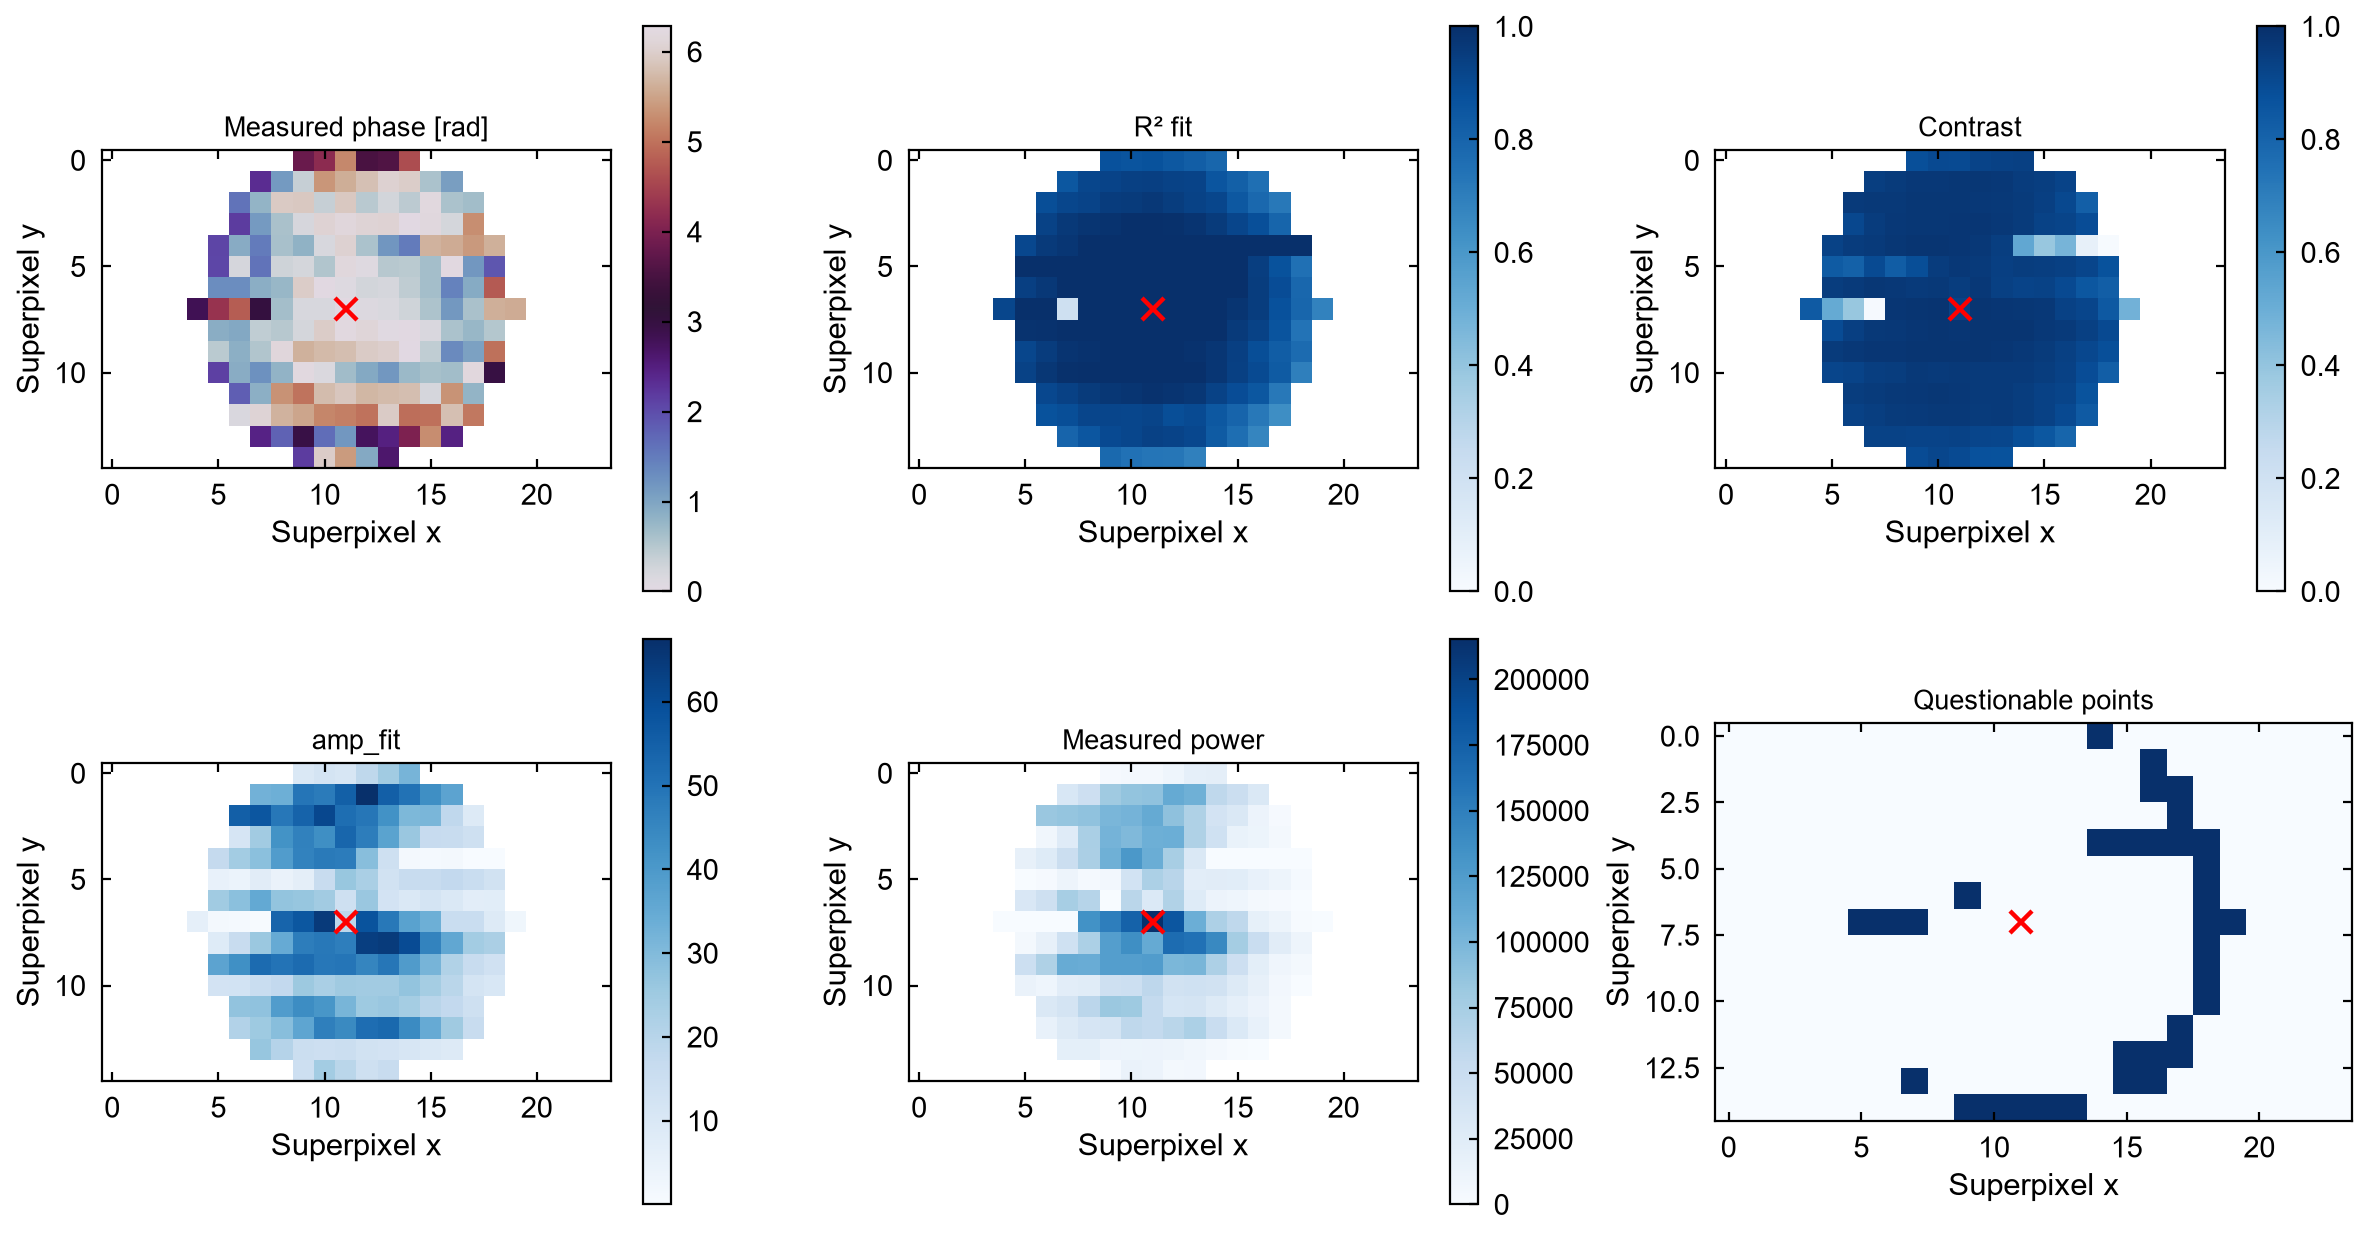

Questionable active points: [[ 0 14]
 [ 1 16]
 [ 2 16]
 [ 2 17]
 [ 3 17]
 [ 4 14]
 [ 4 15]
 [ 4 16]
 [ 4 17]
 [ 4 18]
 [ 5 18]
 [ 6  9]
 [ 6 18]
 [ 7  5]
 [ 7  6]
 [ 7  7]
 [ 7 18]
 [ 7 19]
 [ 8 18]
 [ 9 18]
 [10 18]
 [11 17]
 [12 15]
 [12 16]
 [12 17]
 [13  7]
 [13 15]
 [13 16]
 [14  9]
 [14 10]
 [14 11]
 [14 12]
 [14 13]]

Number questionable: 33


In [22]:
# ============================================================
# NEXT CELL — Plot raw 2D calibration maps
# ============================================================

def active_map(key):
    arr = np.squeeze(np.asarray(raw[key], dtype=float)).copy()

    # Hide everything outside the illuminated footprint
    arr[~active_superpixels] = np.nan

    return arr


phase_map    = active_map("phase")
power_map    = active_map("power")
amp_map      = active_map("amp_fit")
contrast_map = active_map("contrast_fit")
r2_map       = active_map("r2_fit")


fig, axs = plt.subplots(2, 3, figsize=(15, 8))


im = axs[0, 0].imshow(
    phase_map,
    origin="upper",
    cmap="twilight",
    vmin=0,
    vmax=2*np.pi
)
axs[0, 0].set_title("Measured phase [rad]")
plt.colorbar(im, ax=axs[0, 0])


im = axs[0, 1].imshow(
    r2_map,
    origin="upper",
    vmin=0,
    vmax=1
)
axs[0, 1].set_title("R² fit")
plt.colorbar(im, ax=axs[0, 1])


im = axs[0, 2].imshow(
    contrast_map,
    origin="upper",
    vmin=0,
    vmax=1
)
axs[0, 2].set_title("Contrast")
plt.colorbar(im, ax=axs[0, 2])


im = axs[1, 0].imshow(
    amp_map,
    origin="upper"
)
axs[1, 0].set_title("amp_fit")
plt.colorbar(im, ax=axs[1, 0])


im = axs[1, 1].imshow(
    power_map,
    origin="upper"
)
axs[1, 1].set_title("Measured power")
plt.colorbar(im, ax=axs[1, 1])


# Combined "questionable fit" mask
bad_map = (
    active_superpixels
    & (
        (r2_map < 0.8)
        | (contrast_map < 0.8)
        | (power_map <= 0)
    )
)

axs[1, 2].imshow(
    bad_map,
    origin="upper",
    vmin=0,
    vmax=1
)
axs[1, 2].set_title("Questionable points")


# Mark reference superpixel (x=11, y=7)
for ax in axs.ravel():
    ax.plot(11, 7, "rx", markersize=10, markeredgewidth=2)
    ax.set_xlabel("Superpixel x")
    ax.set_ylabel("Superpixel y")


plt.tight_layout()
plt.show()


print("Questionable active points:",
      np.argwhere(bad_map))

print("\nNumber questionable:",
      np.sum(bad_map))

In [23]:
# ============================================================
# NEXT CELL — Diagnose each questionable superpixel
# ============================================================

print(
    " y   x      phase      R2      contrast      power       amp"
)
print("-" * 72)

for y, x in np.argwhere(bad_map):

    ph = phase_map[y, x]
    r2 = r2_map[y, x]
    con = contrast_map[y, x]
    power = power_map[y, x]
    amp = amp_map[y, x]

    reasons = []

    if np.isfinite(r2) and r2 < 0.8:
        reasons.append("R2")
    if np.isfinite(con) and con < 0.8:
        reasons.append("contrast")
    if np.isfinite(power) and power <= 0:
        reasons.append("power")

    print(
        f"{y:2d}  {x:2d}   "
        f"{ph:8.3f}   "
        f"{r2:6.3f}   "
        f"{con:8.3f}   "
        f"{power:9.1f}   "
        f"{amp:7.2f}   "
        f"{','.join(reasons)}"
    )

 y   x      phase      R2      contrast      power       amp
------------------------------------------------------------------------
 0  14      4.613    0.792      0.934     20684.0     31.82   R2
 1  16      1.081    0.757      0.925     30475.0     36.76   R2
 2  16      0.580    0.784      0.904     11901.0     18.01   R2
 2  17      0.656    0.720      0.818      1872.0      8.84   R2
 3  17      5.288    0.796      0.890      4179.0     13.94   R2
 4  14      1.508    1.000      0.529        38.0      1.52   contrast
 4  15      5.656    1.000      0.390         0.0      0.91   contrast,power
 4  16      5.593    1.000      0.470         0.0      1.24   contrast,power
 4  17      5.405    1.000      0.080         0.0      0.17   contrast,power
 4  18      5.630    1.000      0.008         0.0      0.02   contrast,power
 5  18      1.902    0.750      0.869      3083.0     12.99   R2
 6   9      5.969    1.000      0.958         0.0     26.46   power
 6  18      4.759    0.786   

In [24]:
# ============================================================
# NEXT CELL — Inspect installed wavefront processing API
# Nothing is modified
# ============================================================

import inspect

candidates = [
    name for name in dir(fs)
    if ("wavefront" in name.lower() and
        "process" in name.lower())
]

print("Candidate processing methods:")
print(candidates)

for name in candidates:
    func = getattr(fs, name)

    print("\n" + "="*70)
    print(name)
    print("="*70)

    try:
        print("Signature:")
        print(inspect.signature(func))
    except Exception as e:
        print("Could not read signature:", e)

    print("\nDocstring:")
    print(inspect.getdoc(func))

Candidate processing methods:
['_wavefront_calibration_superpixel_process_r001', 'wavefront_calibration_superpixel_process']

_wavefront_calibration_superpixel_process_r001
Signature:
(data, smooth=True, r2_threshold=0.9, remove_vortices=False, remove_blaze=True, remove_background=True, apply=True, plot=False)

Docstring:
Old wavefront calibration processing for release 0.0.1.
See docstring for :meth:`wavefront_calibration_superpixel_process`.

Returns
-------
dict
    The updated source dictionary containing the processed source amplitude and phase.

wavefront_calibration_superpixel_process
Signature:
(index=0, smooth=True, r2_threshold=0.9, remove_vortices=False, remove_blaze=True, remove_background=True, apply=True, plot=False)

Docstring:
Processes :attr:`~slmsuite.hardware.cameraslms.FourierSLM.calibrations` ``["wavefront"]``
into the desired phase correction and amplitude measurement. Applies these
parameters to the respective variables in the SLM if ``apply`` is ``True``.

Param

In [25]:
# ============================================================
# NEXT CELL — Inspect exact processing implementation
# Nothing is applied to the SLM
# ============================================================

import inspect

src = inspect.getsource(
    fs.wavefront_calibration_superpixel_process
)

print(src)

    def wavefront_calibration_superpixel_process(
        self,
        index=0,
        smooth=True,
        r2_threshold=0.9,
        remove_vortices=False,
        remove_blaze=True,
        remove_background=True,
        apply=True,
        plot=False
    ):
        """
        Processes :attr:`~slmsuite.hardware.cameraslms.FourierSLM.calibrations` ``["wavefront"]``
        into the desired phase correction and amplitude measurement. Applies these
        parameters to the respective variables in the SLM if ``apply`` is ``True``.

        Parameters
        ----------
        index : int
            The calibration point index to process, in the case of a multi-point calibration.
            In the future, this should include the option to request an "ij" position,
            then the return will automatically interpolate between the Zernike results
            of the local calibration points.
        smooth : bool OR int
            Whether to blur the correction data to avoid a

In [26]:
# ============================================================
# NEXT CELL — Inspect actual processing algorithm
# Nothing is modified or applied
# ============================================================

import inspect

src_r001 = inspect.getsource(
    fs._wavefront_calibration_superpixel_process_r001
)

print(src_r001)

    def _wavefront_calibration_superpixel_process_r001(
            self,
            data,
            smooth=True,
            r2_threshold=0.9,
            remove_vortices=False,
            remove_blaze=True,
            remove_background=True,
            apply=True,
            plot=False,
        ):
        """
        Old wavefront calibration processing for release 0.0.1.
        See docstring for :meth:`wavefront_calibration_superpixel_process`.

        Returns
        -------
        dict
            The updated source dictionary containing the processed source amplitude and phase.
        """
        # Parse smooth.
        if smooth is True:
            smooth = 16
        smooth = int(smooth)
        if smooth < 0:
            raise ValueError("Smoothing iterations must be a non-negative integer.")

        # Parse r2_threshold.
        r2_threshold = float(r2_threshold)

        # Step 0: Initialize helper variables and functions.
        if len(data) == 0:
            

Active superpixels       : 180
Good measured phase seeds: 164
Manually rejected seeds  : 16

Rejected [y,x]:
[[ 4 14]
 [ 4 15]
 [ 4 16]
 [ 4 17]
 [ 4 18]
 [ 5  6]
 [ 5  8]
 [ 7  5]
 [ 7  6]
 [ 7  7]
 [ 7 19]
 [10 18]
 [12 17]
 [13 16]
 [14 13]
 [14 14]]


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameraslms.py:3778: RuntimeWarning: divide by zero encountered in divide
  pwr_norm = np.divide(pwr, norm)


smooth:   0%|          | 0/16 [00:00<?, ?it/s]

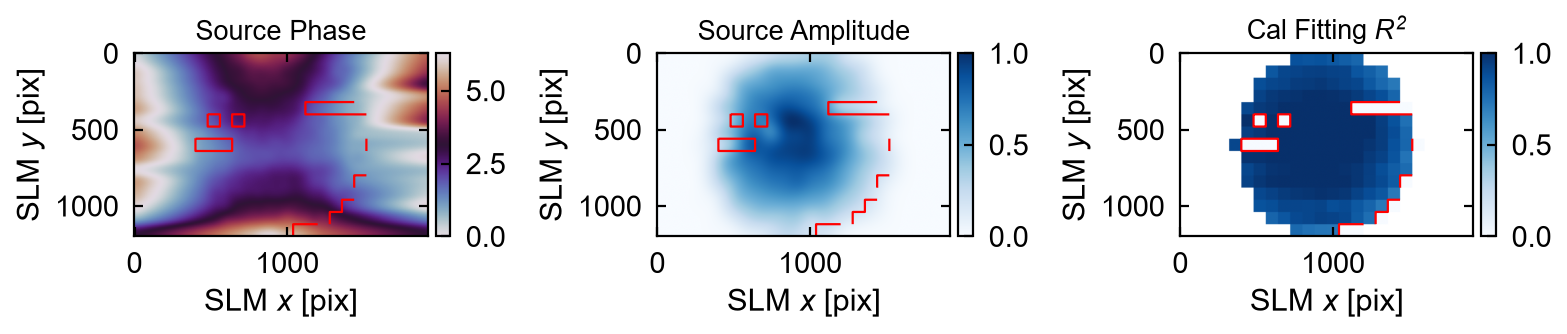


Raw r2 restored: True

Processed phase shape: (1200, 1920)
Processed amplitude shape: (1200, 1920)


In [27]:
# ============================================================
# NEXT CELL — SAFE PROCESSING PREVIEW
#
# Temporarily reject pathological phase fits,
# process with apply=False, then restore raw calibration.
# ============================================================

data = fs.calibrations["wavefront_superpixel"]

r2_raw = np.asarray(data["r2_fit"][0])
contrast_raw = np.asarray(data["contrast_fit"][0])
amp_raw = np.asarray(data["amp_fit"][0])

# Conservative definition of a trustworthy measured phase seed.
quality_seed = (
    active_superpixels
    & np.isfinite(r2_raw)
    & np.isfinite(contrast_raw)
    & np.isfinite(amp_raw)
    & (r2_raw >= 0.70)
    & (contrast_raw >= 0.70)
    & (amp_raw >= 5.0)
)

# Reference superpixel is reconstructed internally from neighbors,
# so do not deliberately reject it here.
force_bad = active_superpixels & ~quality_seed
force_bad[7, 11] = False

print("Active superpixels       :", np.sum(active_superpixels))
print("Good measured phase seeds:", np.sum(quality_seed))
print("Manually rejected seeds  :", np.sum(force_bad))

print("\nRejected [y,x]:")
print(np.argwhere(force_bad))


# ------------------------------------------------------------
# Temporarily modify ONLY r2_fit.
# The original raw data are restored afterward.
# ------------------------------------------------------------

r2_backup = data["r2_fit"].copy()

try:

    data["r2_fit"][0, force_bad] = 0.0

    processed_preview = fs.wavefront_calibration_superpixel_process(
        index=0,

        smooth=True,           # installed default = 16 iterations
        r2_threshold=0.70,

        remove_vortices=False,
        remove_blaze=True,

        # Lab is dark and we did not explicitly measure background.
        # Avoid introducing a background-estimation heuristic for now.
        remove_background=False,

        apply=False,           # IMPORTANT: nothing applied to SLM
        plot=True,
    )

finally:

    # Restore the untouched raw measurement in memory.
    data["r2_fit"][:] = r2_backup


print("\nRaw r2 restored:",
      np.allclose(
          data["r2_fit"],
          r2_backup,
          equal_nan=True
      ))

print("\nProcessed phase shape:",
      processed_preview["phase"].shape)

print("Processed amplitude shape:",
      processed_preview["amplitude"].shape)


Processing R2 threshold = 0.70


smooth:   0%|          | 0/16 [00:00<?, ?it/s]


Processing R2 threshold = 0.80


smooth:   0%|          | 0/16 [00:00<?, ?it/s]


Processing R2 threshold = 0.90


smooth:   0%|          | 0/16 [00:00<?, ?it/s]


Wrapped phase differences relative to threshold = 0.70
------------------------------------------------------

0.70 vs 0.80
RMS difference [rad]    : 0.07819399775515147
Median |difference|     : 0.04143612897301274
95% |difference| [rad]  : 0.16591875853452262

0.70 vs 0.90
RMS difference [rad]    : 0.11042321096891632
Median |difference|     : 0.00706319866035332
95% |difference| [rad]  : 0.2512950974586432


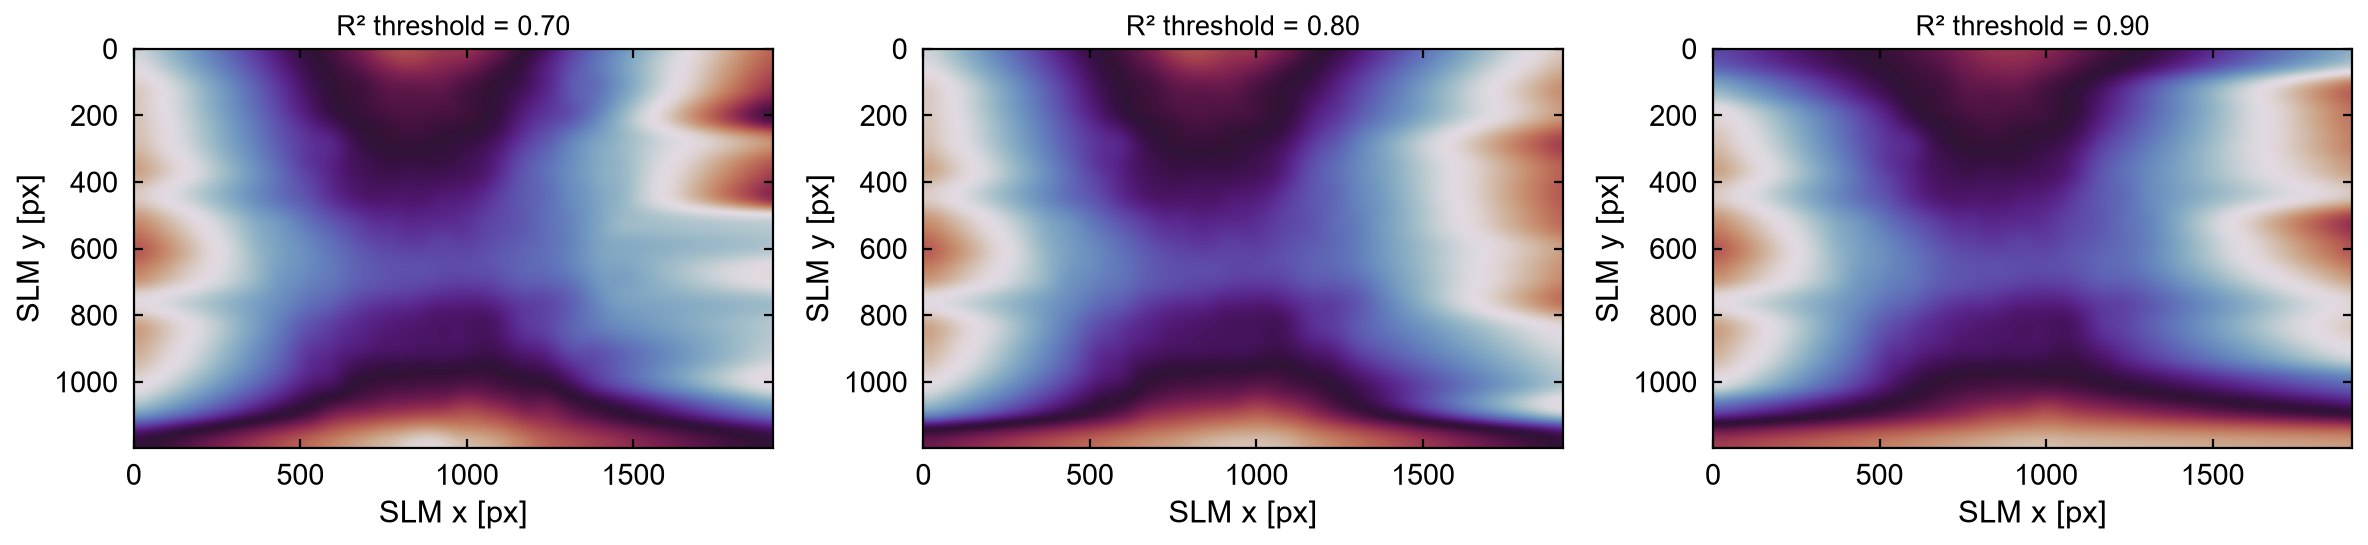

In [28]:
# ============================================================
# NEXT CELL — Processing robustness versus R² threshold
# Nothing is applied to the SLM
# ============================================================

data = fs.calibrations["wavefront_superpixel"]

r2_backup = data["r2_fit"].copy()

thresholds = [0.70, 0.80, 0.90]
processed = {}

try:

    # Keep our manual rejection of obviously pathological
    # low-contrast / low-amplitude fits.
    data["r2_fit"][0, force_bad] = 0.0

    for thr in thresholds:

        print(f"\nProcessing R2 threshold = {thr:.2f}")

        processed[thr] = fs.wavefront_calibration_superpixel_process(
            index=0,
            smooth=True,
            r2_threshold=thr,

            remove_vortices=False,
            remove_blaze=True,
            remove_background=False,

            apply=False,
            plot=False,
        )

finally:

    # Restore completely untouched raw r2 data
    data["r2_fit"][:] = r2_backup


# ------------------------------------------------------------
# Full-resolution version of our circular active footprint
# ------------------------------------------------------------

active_large = np.repeat(
    np.repeat(active_superpixels, SUPERPIXEL_SIZE, axis=0),
    SUPERPIXEL_SIZE,
    axis=1
)

active_large = active_large[
    :slm.shape[0],
    :slm.shape[1]
]


# ------------------------------------------------------------
# Compare phases correctly modulo 2π
# ------------------------------------------------------------

reference_phase = processed[0.70]["phase"]

print("\nWrapped phase differences relative to threshold = 0.70")
print("------------------------------------------------------")

for thr in [0.80, 0.90]:

    phase_test = processed[thr]["phase"]

    dphi = np.angle(
        np.exp(1j * (phase_test - reference_phase))
    )

    vals = dphi[active_large]

    print(f"\n0.70 vs {thr:.2f}")
    print("RMS difference [rad]    :", np.sqrt(np.mean(vals**2)))
    print("Median |difference|     :", np.median(np.abs(vals)))
    print("95% |difference| [rad]  :", np.percentile(np.abs(vals), 95))


# ------------------------------------------------------------
# Display the three processed phase maps
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, thr in zip(axs, thresholds):

    im = ax.imshow(
        processed[thr]["phase"],
        origin="upper",
        cmap="twilight",
        vmin=0,
        vmax=2*np.pi
    )

    ax.set_title(f"R² threshold = {thr:.2f}")
    ax.set_xlabel("SLM x [px]")
    ax.set_ylabel("SLM y [px]")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# FINAL PHASE PROCESSING + PHASE-ONLY INSTALLATION
# ============================================================

data = fs.calibrations["wavefront_superpixel"]

# Preserve untouched raw R2 data
r2_backup = data["r2_fit"].copy()

try:

    # Manually reject the pathological low-contrast / low-amplitude
    # phase measurements identified earlier.
    data["r2_fit"][0, force_bad] = 0.0

    final_wavefront = fs.wavefront_calibration_superpixel_process(
        index=0,

        smooth=True,          # 16 smoothing iterations
        r2_threshold=0.80,

        remove_vortices=False,
        remove_blaze=True,
        remove_background=False,

        apply=False,          # IMPORTANT
        plot=False,
    )

finally:

    # Restore raw calibration exactly
    data["r2_fit"][:] = r2_backup


# ------------------------------------------------------------
# Install ONLY the measured phase correction.
# Do not install the questionable processed amplitude map.
# ------------------------------------------------------------

slm.source.update({
    "phase": final_wavefront["phase"]
})


print("Final correction phase shape:",
      final_wavefront["phase"].shape)

print("Phase min [rad]:",
      np.nanmin(final_wavefront["phase"]))

print("Phase max [rad]:",
      np.nanmax(final_wavefront["phase"]))

print("\nSLM source keys:")
print(slm.source.keys())

print("\nPhase correction installed in slm.source:")
print(
    np.allclose(
        slm.source["phase"],
        final_wavefront["phase"],
        equal_nan=True
    )
)

smooth:   0%|          | 0/16 [00:00<?, ?it/s]

Final correction phase shape: (1200, 1920)
Phase min [rad]: 0.0
Phase max [rad]: 6.2831762207757835

SLM source keys:
dict_keys(['phase'])

Phase correction installed in slm.source:
True


In [30]:
# ============================================================
# SAVE FINAL PROCESSED PHASE CORRECTION
# ============================================================

FINAL_PHASE_PATH = (
    FOURIER_CAL_PATH.parent /
    "YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)

np.save(
    FINAL_PHASE_PATH,
    final_wavefront["phase"]
)

print("Saved processed phase to:")
print(FINAL_PHASE_PATH)

print("\nShape:", final_wavefront["phase"].shape)
print("Finite:", np.all(np.isfinite(final_wavefront["phase"])))

Saved processed phase to:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy

Shape: (1200, 1920)
Finite: True


In [31]:
# ============================================================
# NEXT CELL — Inspect installed Fourier calibration API
# Nothing is changed
# ============================================================

import inspect

fourier_methods = [
    name for name in dir(fs)
    if ("fourier" in name.lower() and
        "calibr" in name.lower())
]

print("Fourier calibration methods:")
print(fourier_methods)

for name in fourier_methods:
    func = getattr(fs, name)

    print("\n" + "="*70)
    print(name)
    print("="*70)

    try:
        print("Signature:")
        print(inspect.signature(func))
    except Exception as e:
        print("Could not read signature:", e)

    print("\nDocstring:")
    print(inspect.getdoc(func))

Fourier calibration methods:
['_check_fourier_calibration_stale', 'fourier_calibrate', 'fourier_calibrate_analytic', 'fourier_calibration_build']

_check_fourier_calibration_stale
Signature:
()

Docstring:
Checks if the wavefront calibration is newer than the Fourier calibration.

Warns if this is true. Does nothing if either calibration is not present or
if another error occurs.

fourier_calibrate
Signature:
(array_shape=10, array_pitch=10, array_center=None, plot=False, autofocus=False, autoexposure=False, **kwargs)

Docstring:
Project and fit a SLM computational Fourier space ``"knm"`` grid onto
camera pixel space ``"ij"`` for affine fitting.
An array produced by
:meth:`~slmsuite.holography.algorithms.SpotHologram.make_rectangular_array()`
is projected for analysis by
:meth:`~slmsuite.holography.analysis.blob_array_detect()`.
These arguments are in ``"knm"`` space because:

- The ``"ij"`` space has not yet been calibrated.
- The ``"kxy"`` space can lead to non-integer ``array_pitch`

In [32]:
# ============================================================
# NEXT CELL — Inspect Fourier projection API
# Nothing is projected yet
# ============================================================

import inspect

print("fourier_grid_project signature:")
print(inspect.signature(fs.fourier_grid_project))

print("\nDocstring:")
print(inspect.getdoc(fs.fourier_grid_project))

fourier_grid_project signature:
(array_shape=10, array_pitch=10, array_center=None, **kwargs)

Docstring:
Projects a Fourier space grid ``"knm"`` onto pixel space ``"ij"``.
The chosen computational :math:`k`-space ``"knm"`` uses a computational shape generated by
:meth:`~slmsuite.holography.algorithms.SpotHologram.get_padded_shape()`
corresponding to the smallest square shape with power-of-two sidelength that is
larger than the SLM's shape.

Parameters
----------
array_shape, array_pitch
    Passed to :meth:`~slmsuite.holography.algorithms.SpotHologram.make_rectangular_array()`
    **in the** ``"knm"`` **basis.**
array_center
    Passed to :meth:`~slmsuite.holography.algorithms.SpotHologram.make_rectangular_array()`
    **in the** ``"knm"`` **basis.**  ``array_center`` is not passed directly, and is
    processed as being relative to the center of ``"knm"`` space, the position
    of the 0th order.
**kwargs
    Passed to :meth:`~slmsuite.holography.algorithms.SpotHologram.optimize()`.


In [33]:
# ============================================================
# NEXT CELL — Inspect how fourier_grid_project writes the hologram
# Nothing is projected manually
# ============================================================

import inspect

src = inspect.getsource(fs.fourier_grid_project)

print(src)

    def fourier_grid_project(self, array_shape=10, array_pitch=10, array_center=None, **kwargs):
        """
        Projects a Fourier space grid ``"knm"`` onto pixel space ``"ij"``.
        The chosen computational :math:`k`-space ``"knm"`` uses a computational shape generated by
        :meth:`~slmsuite.holography.algorithms.SpotHologram.get_padded_shape()`
        corresponding to the smallest square shape with power-of-two sidelength that is
        larger than the SLM's shape.

        Parameters
        ----------
        array_shape, array_pitch
            Passed to :meth:`~slmsuite.holography.algorithms.SpotHologram.make_rectangular_array()`
            **in the** ``"knm"`` **basis.**
        array_center
            Passed to :meth:`~slmsuite.holography.algorithms.SpotHologram.make_rectangular_array()`
            **in the** ``"knm"`` **basis.**  ``array_center`` is not passed directly, and is
            processed as being relative to the center of ``"knm"`` space, the posi

In [34]:
# ============================================================
# NEXT CELL — Does slm.set_phase() apply source phase correction?
# Nothing is written to the SLM
# ============================================================

import inspect

print("set_phase signature:")
print(inspect.signature(slm.set_phase))

print("\nDocstring:")
print(inspect.getdoc(slm.set_phase))

set_phase signature:
(phase, phase_correct: bool = None, settle: bool = None, execute: bool = None, block: bool = None, **kwargs)

Docstring:
Checks, cleans, and adds to data, then sends the data to the SLM and
potentially waits for ``settle_time_s`` seconds. This method calls the
SLM-specific private method :meth:`_format_phase_hw()` (if implemented)
to format the phase data before calling :meth:`_set_phase_hw()` which
transfers the data to the SLM.

Warning
~~~~~~~
Subclasses implementing vendor-specific software *should not* overwrite this
method. Subclasses *should* overwrite :meth:`_set_phase_hw()` (and
:meth:`_format_phase_hw()` if required) instead.

Caution
~~~~~~~
The sign on ``phase`` is flipped before converting to integer data.
This is to convert between the 'increasing value ==> increasing voltage
(= decreasing phase delay)' convention in most SLMs and
:mod:`slmsuite`'s 'increasing value ==> increasing phase delay'
convention. As a result, zero phase will appear entirely w

In [35]:
# ============================================================
# VERIFY WAVEFRONT CORRECTION WILL BE USED
# ============================================================

print("slm.phase_correct =", slm.phase_correct)

print(
    "Phase correction present:",
    "phase" in slm.source
)

if "phase" in slm.source:
    print("Correction shape:", slm.source["phase"].shape)
    print("Correction min  :", np.min(slm.source["phase"]))
    print("Correction max  :", np.max(slm.source["phase"]))

slm.phase_correct = True
Phase correction present: True
Correction shape: (1200, 1920)
Correction min  : 0.0
Correction max  : 6.2831762207757835


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameraslms.py:1373: UserWarning: The wavefront calibration is newer (2026-09-03 21:09:49.840909) than the Fourier calibration (2026-09-03 15:03:12.693725). The Fourier calibration may be stale.
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

Camera exposure [s]: 0.049997180999999995
Image min : 0
Image max : 44
Image mean: 4.964989392166377e-05


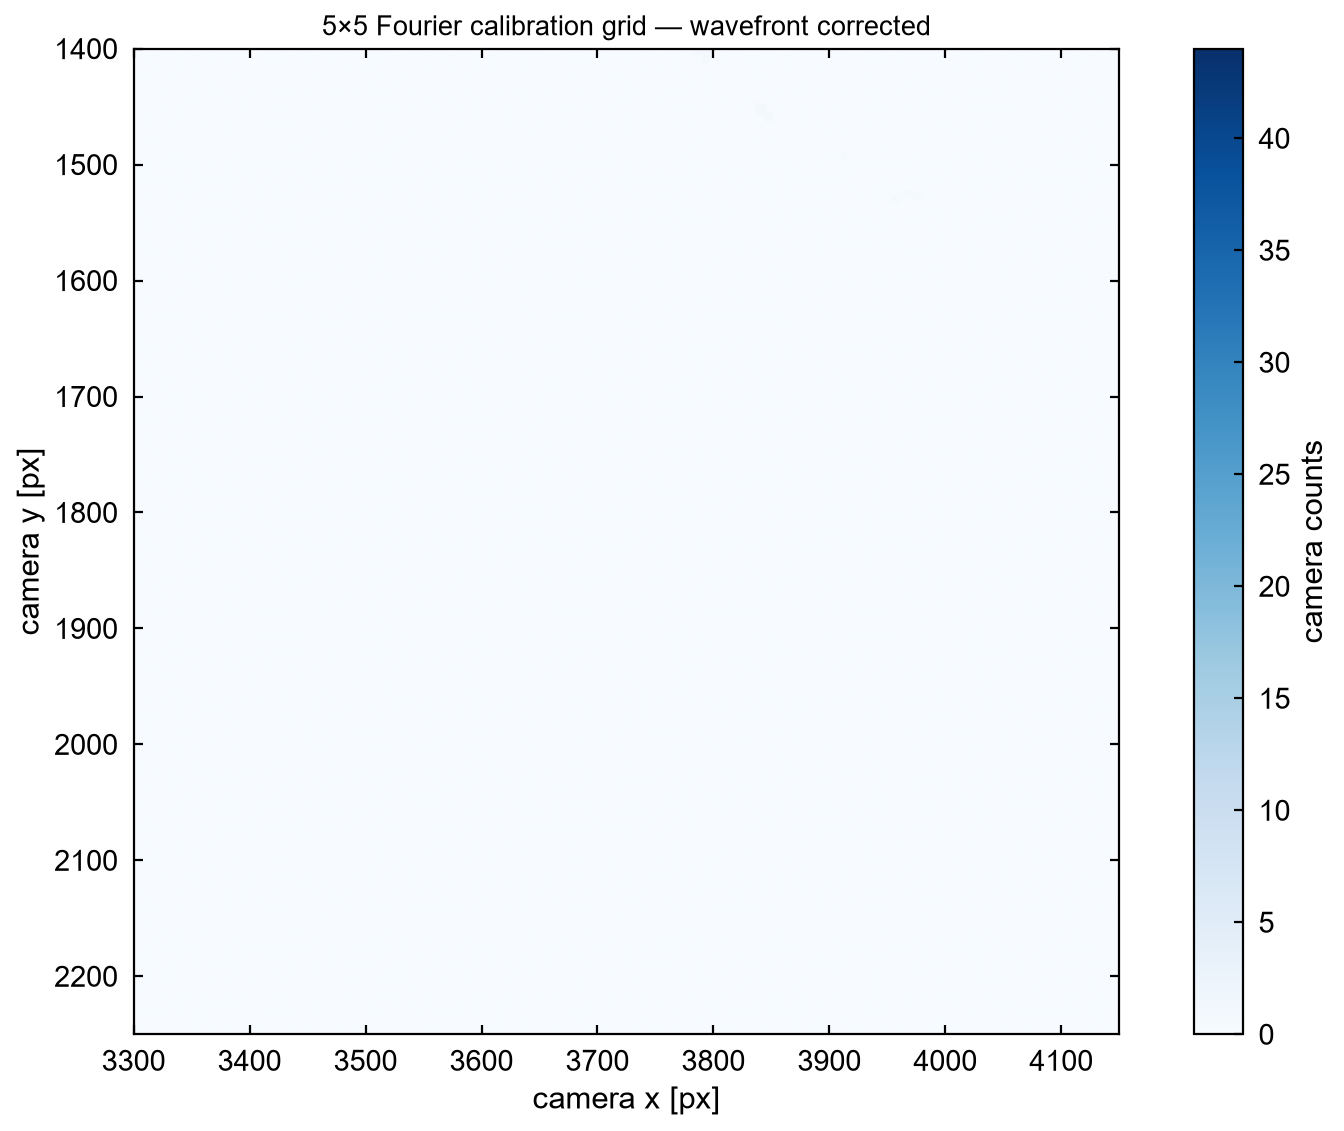

In [36]:
# ============================================================
# NEXT CELL — Project post-wavefront Fourier calibration array
# Same geometry as the original successful calibration
# ============================================================

fourier_holo_post = fs.fourier_grid_project(
    array_shape=(5, 5),
    array_pitch=(13, 13),
    array_center=(128, 0),

    method="GS",
    maxiter=10,
)

# Make sure we acquire a fresh frame after the new SLM pattern
cam.flush()
img_fourier_post = cam.get_image()

print("Camera exposure [s]:", cam.exposure_s)
print("Image min :", img_fourier_post.min())
print("Image max :", img_fourier_post.max())
print("Image mean:", img_fourier_post.mean())

plt.figure(figsize=(12, 8))
plt.imshow(img_fourier_post, origin="upper")
plt.xlim(3300, 4150)
plt.ylim(2250, 1400)
plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title("5×5 Fourier calibration grid — wavefront corrected")
plt.colorbar(label="camera counts")
plt.show()

CORRECTION OFF
full-frame max : 255
full max [y,x]: (np.int64(1778), np.int64(4357))
ROI max        : 5
ROI max [y,x]  : (np.int64(1839), np.int64(3961))
ROI mean       : 0.016829065743944636

CORRECTION ON
full-frame max : 255
full max [y,x]: (np.int64(1778), np.int64(4359))
ROI max        : 4
ROI max [y,x]  : (np.int64(1838), np.int64(3963))
ROI mean       : 0.01546159169550173


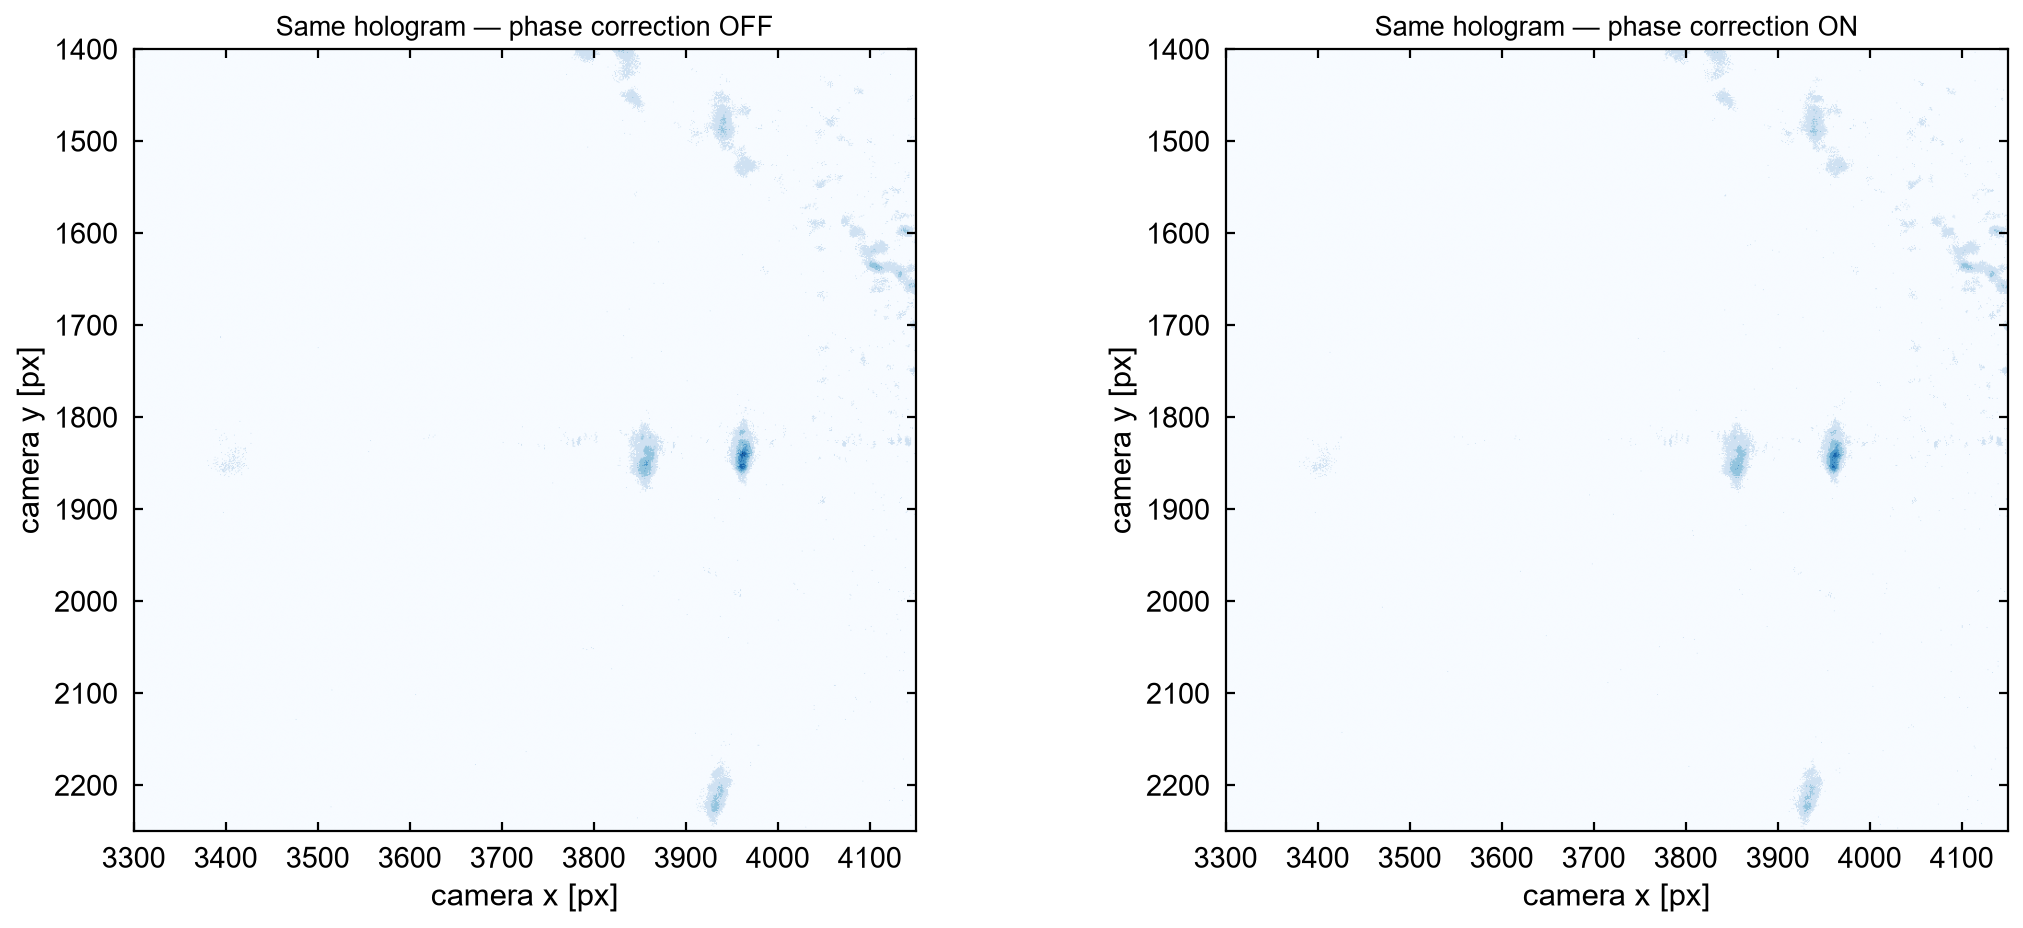

In [41]:
# ============================================================
# A/B TEST — SAME Fourier hologram, correction OFF vs ON
# Do not change optics/exposure/power
# ============================================================

phase_fourier = fourier_holo_post.get_phase()

# Expected calibration-array ROI
x0, x1 = 3300, 4150
y0, y1 = 1400, 2250


def acquire_state(phase_correct):
    slm.set_phase(
        phase_fourier,
        phase_correct=phase_correct,
        settle=True
    )

    cam.flush()
    img = cam.get_image()

    roi = img[y0:y1, x0:x1]

    max_full_yx = np.unravel_index(np.argmax(img), img.shape)
    max_roi_yx  = np.unravel_index(np.argmax(roi), roi.shape)

    max_roi_global_yx = (
        max_roi_yx[0] + y0,
        max_roi_yx[1] + x0
    )

    return img, roi, max_full_yx, max_roi_global_yx


img_off, roi_off, maxfull_off, maxroi_off = acquire_state(False)
img_on,  roi_on,  maxfull_on,  maxroi_on  = acquire_state(True)


print("CORRECTION OFF")
print("full-frame max :", img_off.max())
print("full max [y,x]:", maxfull_off)
print("ROI max        :", roi_off.max())
print("ROI max [y,x]  :", maxroi_off)
print("ROI mean       :", roi_off.mean())

print("\nCORRECTION ON")
print("full-frame max :", img_on.max())
print("full max [y,x]:", maxfull_on)
print("ROI max        :", roi_on.max())
print("ROI max [y,x]  :", maxroi_on)
print("ROI mean       :", roi_on.mean())


fig, axs = plt.subplots(1, 2, figsize=(14, 6))

vmax = max(roi_off.max(), roi_on.max())

axs[0].imshow(
    roi_off,
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[0].set_title("Same hologram — phase correction OFF")
axs[0].set_xlabel("camera x [px]")
axs[0].set_ylabel("camera y [px]")

axs[1].imshow(
    roi_on,
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[1].set_title("Same hologram — phase correction ON")
axs[1].set_xlabel("camera x [px]")
axs[1].set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

Image shape: (3672, 5496)
Global max: 255


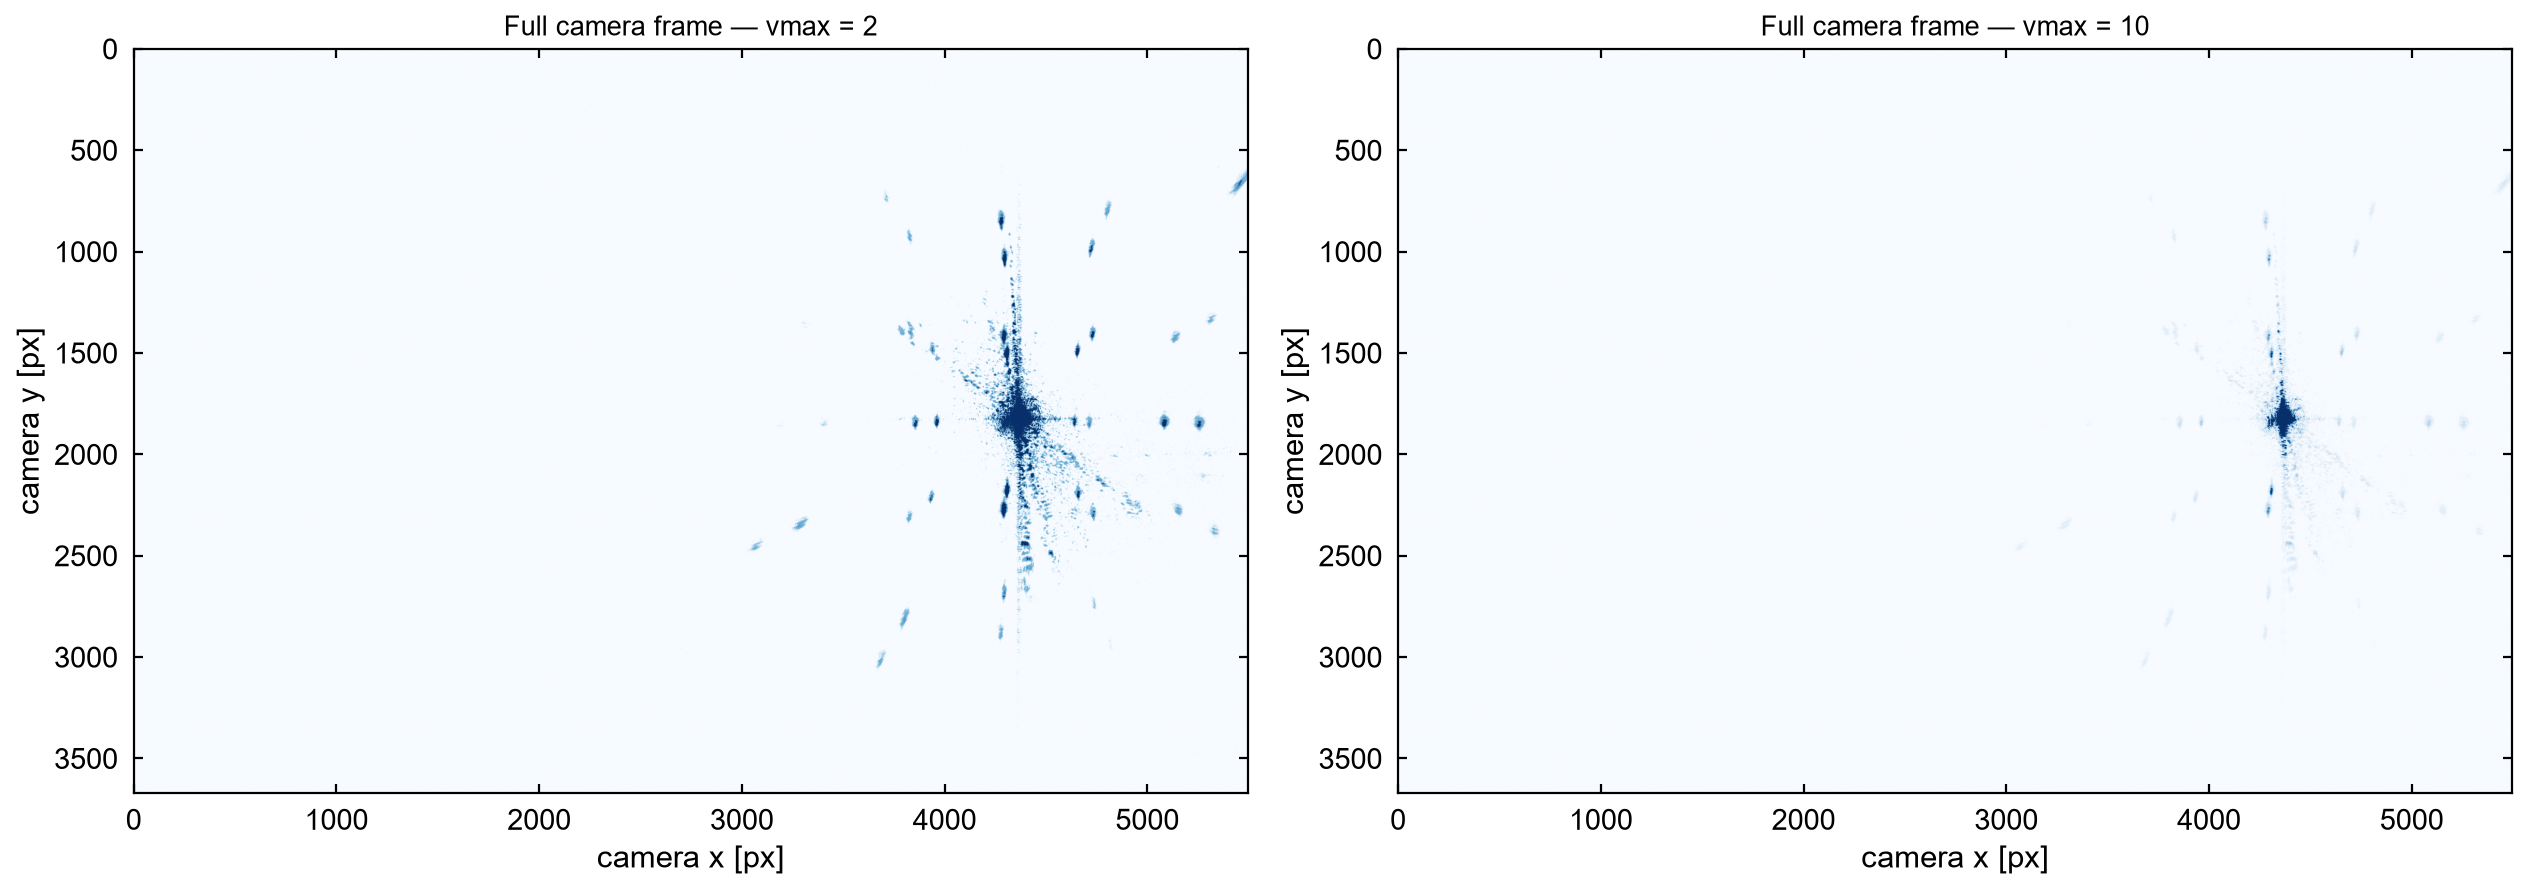


Strongest x positions from column sums:
x=4364   sum=32106.0
x=4363   sum=32101.0
x=4362   sum=31894.0
x=4365   sum=31638.0
x=4361   sum=31346.0
x=4366   sum=30816.0
x=4360   sum=30453.0
x=4367   sum=29657.0
x=4359   sum=29288.0
x=4368   sum=28602.0

Strongest y positions from row sums:
y=1822   sum=17018.0
y=1823   sum=16989.0
y=1824   sum=16888.0
y=1821   sum=16885.0
y=1825   sum=16661.0
y=1820   sum=16599.0
y=1826   sum=16440.0
y=1827   sum=16264.0
y=1828   sum=16258.0
y=1819   sum=15985.0


In [42]:
# ============================================================
# NEXT CELL — Find where the Fourier calibration pattern went
# Use the already-acquired CORRECTION-OFF image
# Nothing is changed experimentally
# ============================================================

img = img_off

print("Image shape:", img.shape)
print("Global max:", img.max())

# Show the complete sensor with a deliberately low display ceiling
# so weak diffraction spots become visible.
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].imshow(
    img,
    origin="upper",
    vmin=0,
    vmax=2
)
axs[0].set_title("Full camera frame — vmax = 2")
axs[0].set_xlabel("camera x [px]")
axs[0].set_ylabel("camera y [px]")

axs[1].imshow(
    img,
    origin="upper",
    vmin=0,
    vmax=10
)
axs[1].set_title("Full camera frame — vmax = 10")
axs[1].set_xlabel("camera x [px]")
axs[1].set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()


# Integrated intensity projections can reveal a weak grid
# even if individual spots are hard to see.
sum_x = np.sum(img.astype(float), axis=0)
sum_y = np.sum(img.astype(float), axis=1)

print("\nStrongest x positions from column sums:")
for x in np.argsort(sum_x)[-10:][::-1]:
    print(f"x={x:4d}   sum={sum_x[x]:.1f}")

print("\nStrongest y positions from row sums:")
for y in np.argsort(sum_y)[-10:][::-1]:
    print(f"y={y:4d}   sum={sum_y[y]:.1f}")